# Marketing Mix Modeling by PyMC-Marketing
*このNotebookでは、MMMをいくつかのパートに分割し、1から詳細に理解を深めることをサポートする。*

## 参考文献
- MMM Example Notebook：https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_example.html#mmm-example
- Splitting MMM Channel Impact Across Campaigns：https://www.pymc-marketing.io/en/stable/notebooks/mmm/mmm_credibility_disaggregation.html


# MMM学習目次

<details>
<summary>Part 0: MMMを学ぶ前の前提知識</summary>

- 0-1. MMMとは
- 0-2. データの基本
- 0-3. 評価指標

</details>

<details>
<summary>Part 1: 統計学の基礎</summary>

- 1-1. 回帰分析
- 1-2. 時系列データ
- 1-3. 前処理

</details>

<details>
<summary>Part 2: MMMのモデル設計</summary>

- 2-1. 線形回帰
- 2-2. 非線形効果
- 2-3. 遅延効果

</details>

<details>
<summary>Part 3: 推定の仕組み</summary>

- 3-1. 最尤推定
- 3-2. 最適化
- 3-3. MCMC
- 3-4. ベイズ推定

</details>

<details>
<summary>Part 4: 実装と診断</summary>

- 4-1. PyMC実装
- 4-2. 推定結果の診断
- 4-3. 感度分析

</details>

# MMM（Maketing Mix Modeling）とは

- Marketing Mix Modeling（MMM：マーケティング・ミックス・モデリング）とは、過去の販売データや広告出稿データ、外部要因などを統計解析（主に重回帰分析や時系列分析）し、各種マーケティング施策が売上や成果にどれだけ貢献したかを定量的に可視化・最適化する手法。

- MMMが重要視される背景

    - Cookie規制・プライバシー保護の強化
        - *サードパーティCookieの規制やAppleのITP導入に伴い、従来型のデジタル広告の個人トラッキング（アトリビューション分析）が困難になりました。個人データを追跡しない集計データベースの手法としてMMMが再評価されています。*

    - オフライン・オンライン施策の断片化
        - *テレビCMや新聞広告などのオフライン施策と、SNS・動画広告などのオンライン施策が混在し、全体としてどの施策がどれだけ効いているかの全貌（横串での比較）が見えにくくなっています。*

    - マクロ経済や外部環境の変動
        - *競合の動き、季節性、物価高、天候などの外部要因が売上に与える影響を分離して施策本来の効果を測定したいというニーズが高まっています。*

## 0. 環境構築

In [ ]:
#%pip show pymc-marketing
#%pip install -q pymc-marketing==1.1.0 

Note: you may need to restart the kernel to use updated packages.


In [1]:
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import xarray as xr
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.mmm import MMM
from pymc_marketing.mmm.transformers import geometric_adstock, logistic_saturation

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

g++ not available, if using conda: `conda install gxx`


## 1. データ作成

### *1-1. Date Range*

In [2]:
seed: int = sum(map(ord, "mmm"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

# date range
min_date = pd.to_datetime("2020-04-01")
max_date = pd.to_datetime("2023-09-01")

df = pd.DataFrame(
    data={"date_week": pd.date_range(start=min_date, end=max_date, freq="W-MON")}
).assign(
    year=lambda x: x["date_week"].dt.year,
    month=lambda x: x["date_week"].dt.month,
    dayofyear=lambda x: x["date_week"].dt.dayofyear,
)

n = df.shape[0]
print(f"Number of observations: {n}")

Number of observations: 178


### *1-2. Media Costs Data*

- 備忘録
    - to_xarray() は、Pandasのデータ（SeriesやDataFrame）を xarray.DataArray という「軸（次元）の名前やラベル情報を持った多次元配列」に変換する関数。`geometric_adstock` では引数 `dim` でindexの名前を求められるため、`to_numpy` ではエラーが起きる。

In [4]:
# media data
tv = rng.uniform(low=0.0, high=1.0, size=n)
df["tv"] = np.where(tv > 0.9, tv, tv / 2)

web = rng.uniform(low=0.0, high=1.0, size=n)
df["web"] = np.where(web > 0.8, web, 0)

# adostock parameters
alpha1: float = 0.5
alpha2: float = 0.2

# TVとWebデータに対してアドストック効果に基づく返還を適用
df["tv_adstock"] = (
    #教科書では".to_numpy()"を使用しているが、最新版docでは".to_xarray()"
    geometric_adstock(x=df["tv"].to_xarray(),
                      alpha=alpha1,
                      l_max=8,
                      dim="index",
                      normalize=True)
    .eval()
    .flatten())

df["web_adstock"] = (
    geometric_adstock(x=df["web"].to_xarray(),
                      alpha=alpha2,
                      l_max=8,
                      dim="index",
                      normalize=True)
    .eval()
    .flatten())

# 形状パラメータを設定
lam1: float = 4.0
lam2: float = 3.0

# TVとwebのアドストックデータに対して形状効果に基づく返還を適用
df["tv_adstock_saturated"] = logistic_saturation(x=df["tv_adstock"].to_xarray(),
                                                lam=lam1).eval()

df["web_adstock_saturated"] = logistic_saturation(x=df["web_adstock"].to_xarray(),
                                                  lam=lam2).eval()

# トレンド項をデータフレームに追加
df["trend"] = (np.linspace(start=0.0, stop=50, num=n) +10) ** (1 / 4) - 1

# 季節項の計算を行い、データフレームに追加
df["cs"] = -np.sin(2 * 2 * np.pi * df["dayofyear"] / 365.5)
df["cc"] = np.cos(1 * 2 * np.pi * df["dayofyear"] / 365.5)
df["seasonality"] = 0.5 * df["cs"] + df["cc"]

# イベント項、切片、誤差項をデータフレームに追加
df["event_1"] = (df["date_week"] == "2021-05-13").astype(float)
df["event_2"] = (df["date_week"] == "2022-09-14").astype(float)

df["intercept"] = 2.0
df["epsilon"] = rng.normal(loc=0.0, scale=0.25, size=n) #誤差項

# TVとWebの効果の係数をサンプルデータ生成のために設定
beta_1 = 3.0
beta_2 = 2.0
betas = [beta_1, beta_2]

# 売上データの作成
df["y"] = df["intercept"]\
    + df["trend"]\
    + df["seasonality"]\
    + 1.5 * df["event_1"]\
    + 2.5 * df["event_2"]\
    + beta_1 * df["tv_adstock_saturated"]\
    + beta_2 * df["web_adstock_saturated"]\
    + df["epsilon"]

- メディアの中での売上シェアを確認

In [5]:
contribution_share_tv: float = (beta_1 * df["tv_adstock_saturated"].sum()) / (
    beta_1 * df["tv_adstock_saturated"] + beta_2 * df["web_adstock_saturated"]).sum()

contribution_share_web: float = (beta_2 * df["web_adstock_saturated"]).sum() / (
    beta_1 * df["tv_adstock_saturated"] + beta_2 * df["web_adstock_saturated"]).sum()

print(f"Contribution Share of tv: {contribution_share_tv:.2f}")
print(f"Contribution Share of web: {contribution_share_web:.2f}")

Contribution Share of tv: 0.80
Contribution Share of web: 0.20


- ROASの確認

In [6]:
roas_tv = (beta_1 * df["tv_adstock_saturated"]).sum() / df["tv"].sum()
roas_web = (beta_2 * df["web_adstock_saturated"]).sum() / df["web"].sum()
print(f"Roas of tv: {roas_tv:.2f}")
print(f"Roas of web: {roas_web:.2f}")

Roas of tv: 5.03
Roas of web: 2.27


- データとして残すcolumnsを記載

In [7]:
columns_to_keep = [
    "date_week",
    "y",
    "tv",
    "web",
    "event_1",
    "event_2",
    "dayofyear",
]

data = df[columns_to_keep].copy()

data["t"] = range(n)

- MMMの学習時に使用する目的変数と説明変数を設定

In [8]:
X = data.drop("y", axis=1)
y = data["y"]

- 合計の広告費の中からTVとWebが占める割合を計算

In [9]:
total_spend_per_channel = data[["tv", "web"]].sum(axis=0)
spend_share = total_spend_per_channel / total_spend_per_channel.sum()
spend_share

tv     0.647741
web    0.352259
dtype: float64

- 事前分布の設定

In [10]:
HALFNORMAL_SCALE = 1 / np.sqrt(1 - 2 / np.pi)

n_channels = 2 #チャネル数

prior_sigma = HALFNORMAL_SCALE * n_channels * spend_share.to_numpy() #事前分布の標準偏差

prior_sigma.tolist()

[2.1490715664262106, 1.1687219135144011]

## 2. 因果効果の推定

### *2-1. model configの設定*

In [11]:
dummy_model = MMM(
    date_column="",
    channel_columns=[""],
    adstock=GeometricAdstock(l_max=4),
    saturation=LogisticSaturation(),
)
dummy_model.default_model_config

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

In [12]:
my_model_config = {
    "intercept": Prior("Normal", mu=0, sigma=2),
    "saturation_beta": Prior("HalfNormal", sigma=prior_sigma, dims="channel"),
    "gamma_control": Prior("Normal", mu=0, sigma=2, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=0.2, dims="fourier_mode"),
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=6)),
}

my_sampler_config = {"progressbar": True}

### *2-2. modelの事前分布*

c:\Users\kzapp\python_training\causal_inference\.venv\Lib\site-packages\pymc_extras\prior.py:851: UserWarning: Implicit conversion of array-like parameter sigma to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning
  return _param_value_with_dims(param, value, dims=self.dims)


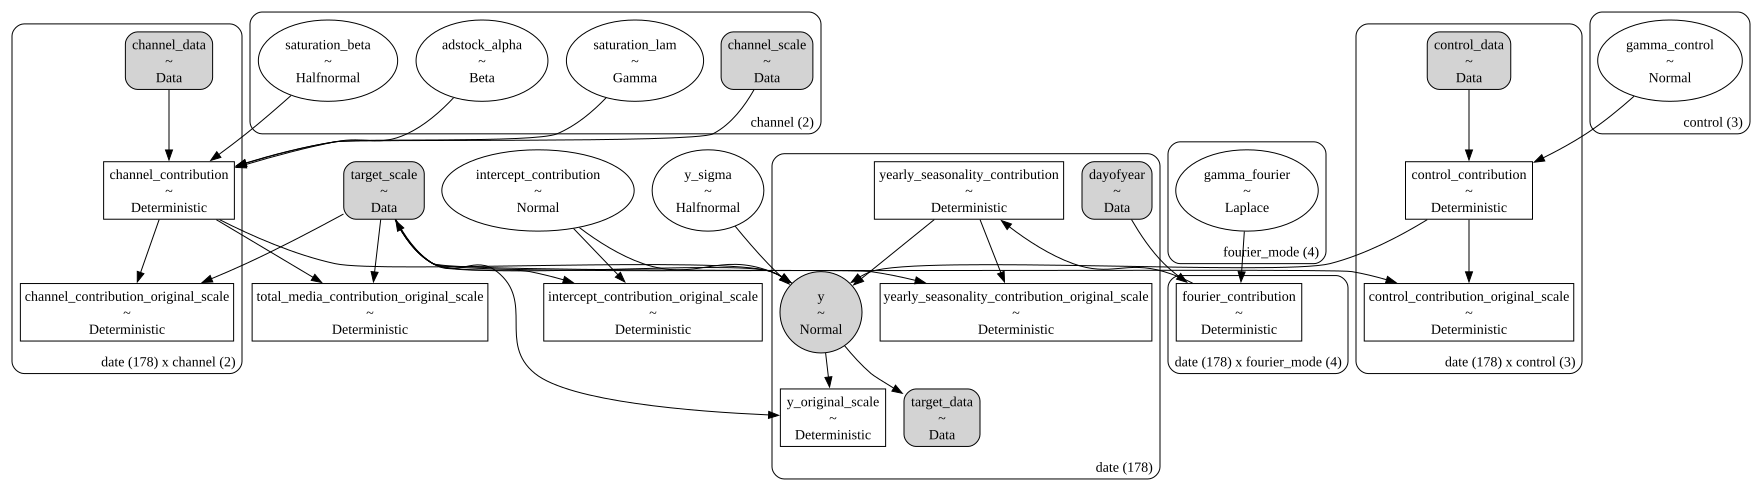

In [ ]:
mmm = MMM(
    model_config=my_model_config,
    sampler_config=my_sampler_config,
    date_column="date_week",
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    channel_columns=["tv", "web"],
    control_columns=["event_1", "event_2", "t"],
    yearly_seasonality=2,
)

mmm.plot_suite = "new"

# Build the model and add contribution variables in original scale
mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(
    var=[
        "channel_contribution",
        "control_contribution",
        "intercept_contribution",
        "yearly_seasonality_contribution",
        "y",
    ]
)

""" 
# import os
# import sys

# # Graphvizのデフォルトインストールパスを追加
# graphviz_path = r"C:\Program Files\Graphviz\bin"

# if graphviz_path not in os.environ["PATH"]:
#     os.environ["PATH"] += os.path.pathsep + graphviz_path
"""

pm.model_to_graphviz(mmm.model)

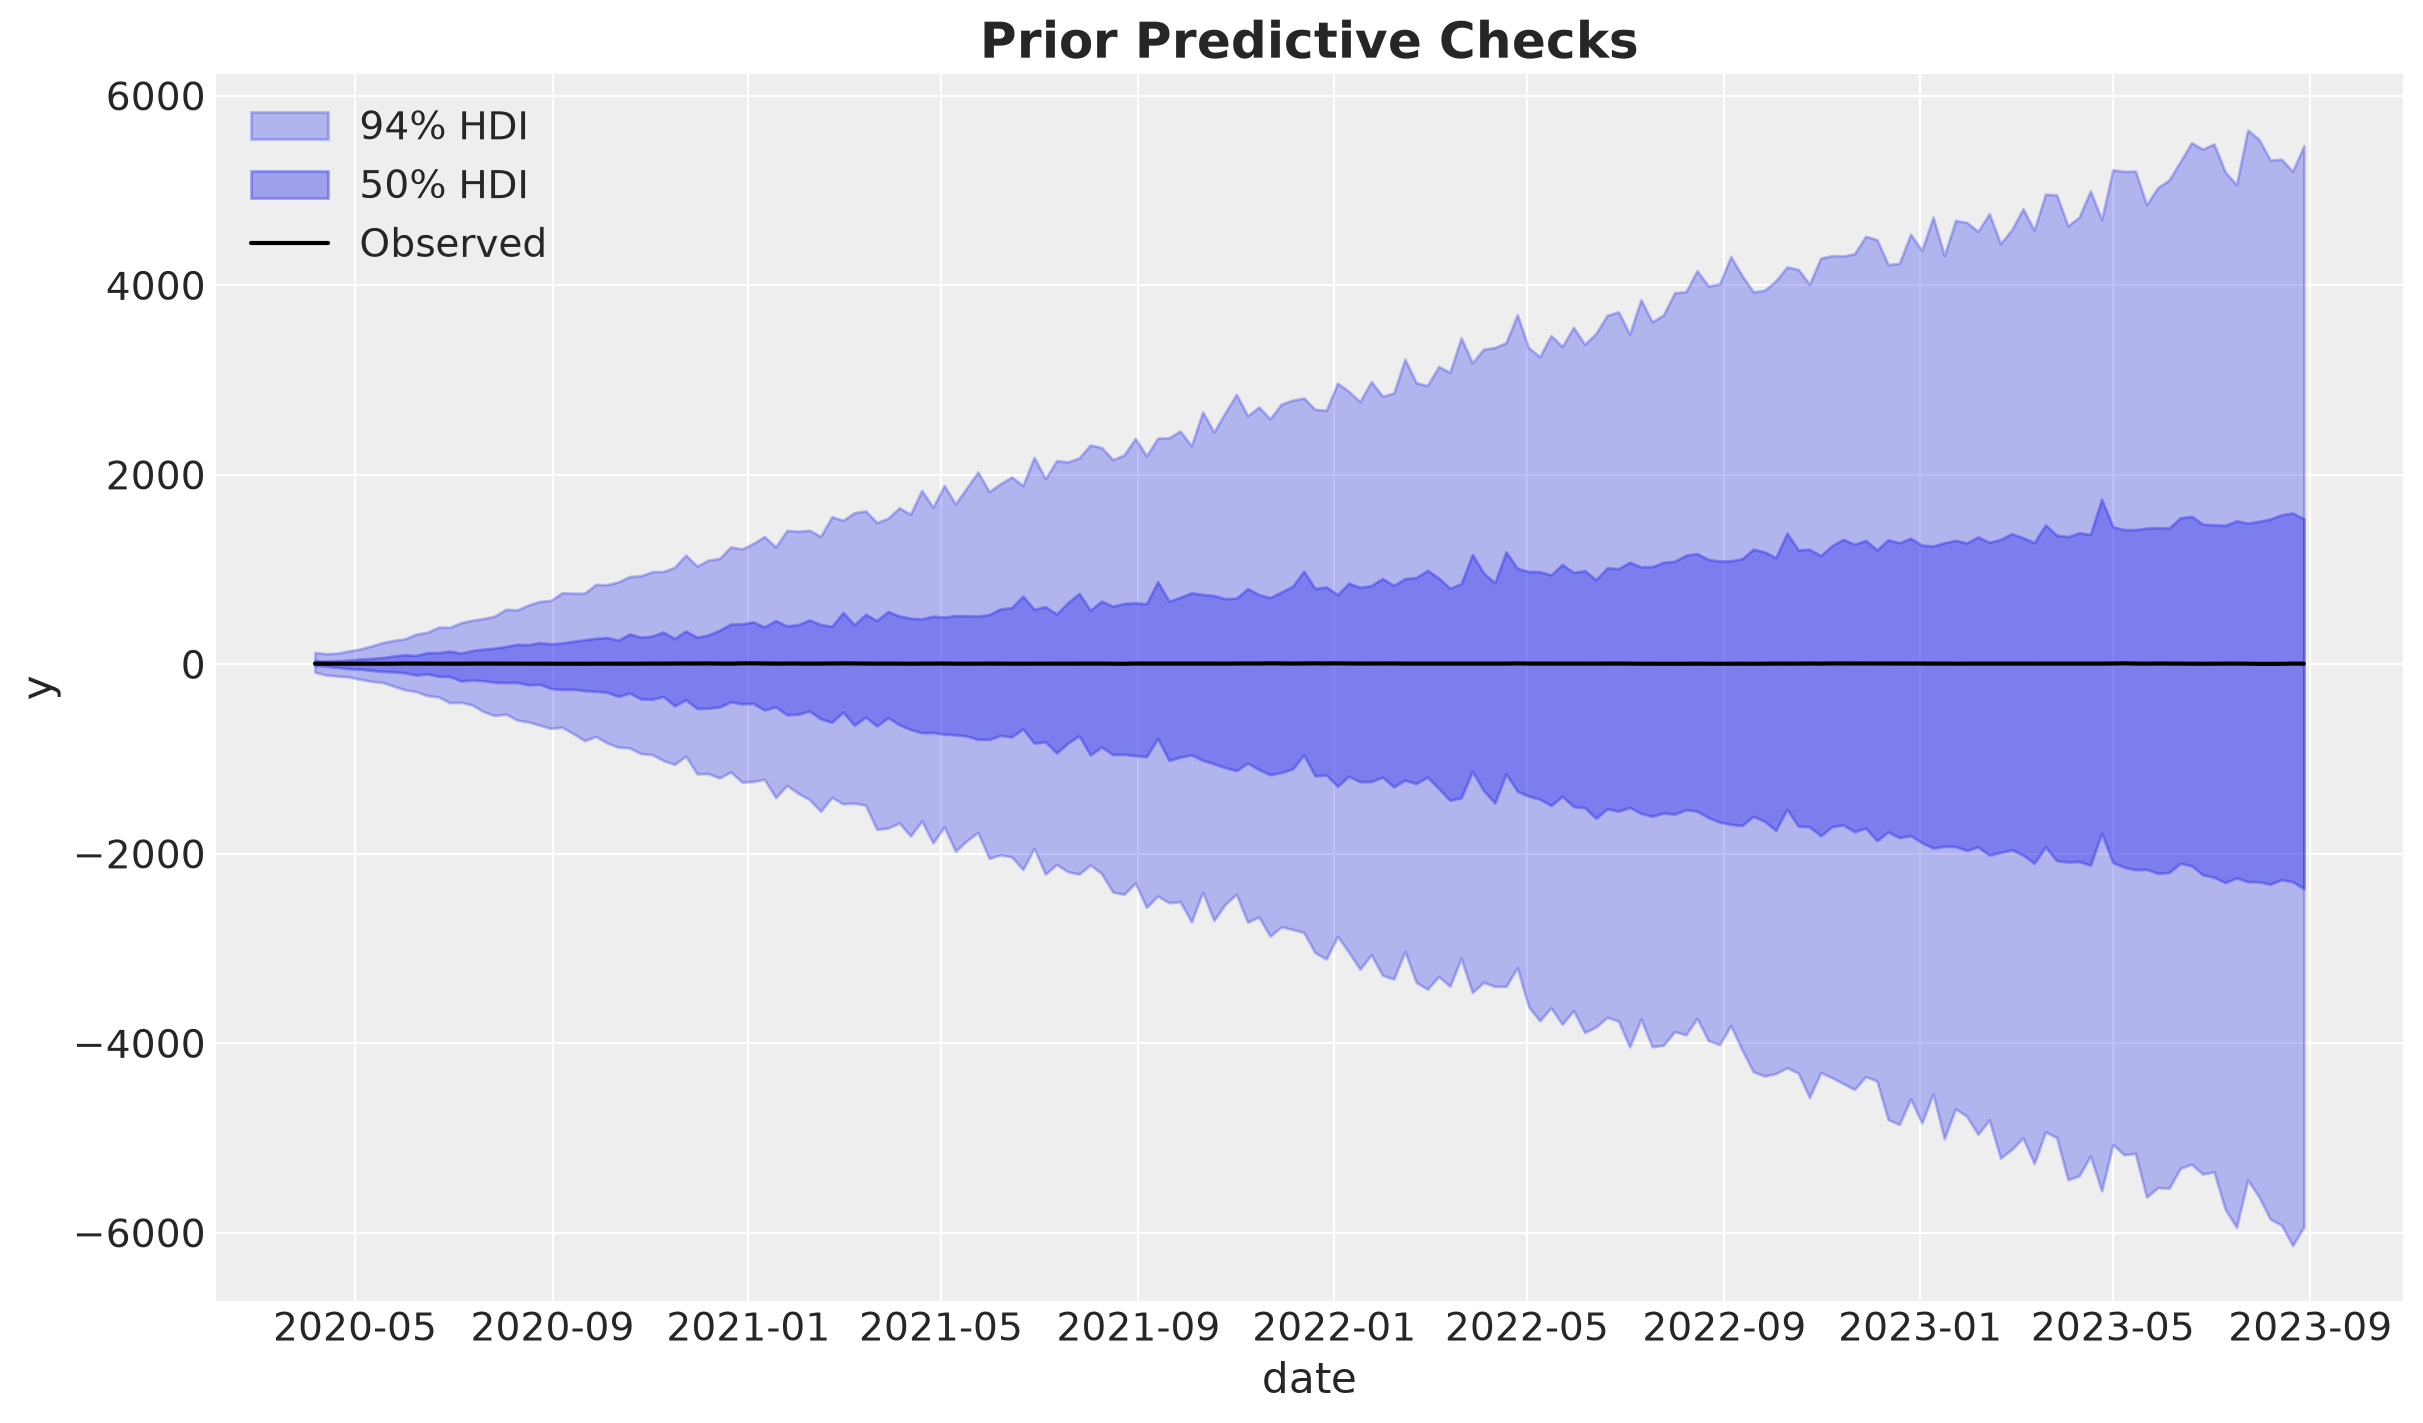

In [17]:
# Custom plot for prior predictive checks
fig, ax = plt.subplots()
for i, hdi_prob in enumerate([0.94, 0.5]):
    hdi = az.hdi(
        mmm.idata["prior"]["y_original_scale"].unstack().transpose(..., "date"),
        prob=hdi_prob,
    )
    ax.fill_between(
        mmm.model.coords["date"],
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=0.3 + i * 0.1,
        label=f"{hdi_prob:.0%} HDI",
    )
sns.lineplot(data=df, x="date_week", y="y", color="black", label="Observed", ax=ax)
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="y")
ax.set_title("Prior Predictive Checks", fontsize=18, fontweight="bold");

### *2-3. モデルのフィッティング*

In [18]:
%%time

mmm.fit(
    X=X,
    y=y,
    chains=4,
    tune=1_500,
    draws=1_000,
    target_accept=0.95,
    random_seed=rng,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 22 seconds.


Output()

CPU times: total: 28 s
Wall time: 46.7 s


<xarray.DataTree>
Group: /
│   Attributes: (12/24)
│       id:                         2b94dbdea32c6855
│       model_type:                 MMMM (Multi-Dimensional Marketing Mix Model)
│       version:                    0.0.2
│       sampler_config:             {"progressbar": true}
│       model_config:               {"intercept": {"dist": "Normal", "kwargs": {"...
│       __serialization_version__:  1
│       ...                         ...
│       scaling:                    {"__type__": "pymc_marketing.mmm.scaling.Scal...
│       dag:                        null
│       treatment_nodes:            null
│       outcome_node:               null
│       mu_effects:                 []
│       cost_per_unit:              null
├── Group: /prior
│       Dimensions:                                         (chain: 1, draw: 2000,
│                                                            date: 178,
│                                                            fourier_mode: 4,
│                                                            control: 3, channel: 2)
│       Coordinates:
│         * chain                                           (chain) int64 8B 0
│         * draw                                            (draw) int64 16kB 0 ... 1999
│         * date                                            (date) datetime64[ns] 1kB ...
│         * fourier_mode                                    (fourier_mode) <U5 80B 's...
│         * control                                         (control) <U7 84B 'event_...
│         * channel                                         (channel) <U3 24B 'tv' 'web'
│       Data variables: (12/17)
│           fourier_contribution                            (chain, draw, date, fourier_mode) float64 11MB ...
│           control_contribution                            (chain, draw, date, control) float64 9MB ...
│           intercept_contribution                          (chain, draw) float64 16kB ...
│           intercept_contribution_original_scale           (chain, draw) float64 16kB ...
│           gamma_control                                   (chain, draw, control) float64 48kB ...
│           adstock_alpha                                   (chain, draw, channel) float64 32kB ...
│           ...                                              ...
│           gamma_fourier                                   (chain, draw, fourier_mode) float64 64kB ...
│           control_contribution_original_scale             (chain, draw, date, control) float64 9MB ...
│           saturation_beta                                 (chain, draw, channel) float64 32kB ...
│           y_original_scale                                (chain, draw, date) float64 3MB ...
│           saturation_lam                                  (chain, draw, channel) float64 32kB ...
│           channel_contribution                            (chain, draw, date, channel) float64 6MB ...
│       Attributes:
│           created_at:                 2026-09-14T07:12:13.571725+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           pymc_marketing_version:     1.1.0
├── Group: /prior_predictive
│       Dimensions:  (chain: 1, draw: 2000, date: 178)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│         * date     (date) datetime64[ns] 1kB 2020-04-06 2020-04-13 ... 2023-08-28
│       Data variables:
│           y        (chain, draw, date) float64 3MB 1.122 -1.019 -2.751 ... 50.35 50.6
│       Attributes:
│           created_at:                 2026-09-14T07:12:13.579486+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_languag

In [20]:
mmm.table()

                                 Variable  Expression                                  Dimensions                  
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                          channel_scale =  Data                                        channel[2]                  
                           target_scale =  Data                                                                    
                           channel_data =  Data                                        date[178] × channel[2]      
                            target_data =  Data                                        date[178]                   
                           control_data =  Data                                        date[178] × control[3]      
                              dayofyear =  Data                                        date[178]                   
                                                                                                                   
                 intercept_contribution ~  Normal(0, 2)                                                            
                          adstock_alpha ~  Beta(1, 3)                                  channel[2]                  
                         saturation_lam ~  Gamma(3, <constant>)                        channel[2]                  
                        saturation_beta ~  HalfNormal(0, <constant>)                   channel[2]                  
                          gamma_control ~  Normal(0, 2)                                control[3]                  
                          gamma_fourier ~  Laplace(0, 0.2)                             fourier_mode[4]             
                                y_sigma ~  HalfNormal(0, 6)                                                        
                                                                                       Parameter count = 15        
                                                                                                                   
                   channel_contribution =  f(saturation_beta, saturation_lam,          date[178] × channel[2]      
                                           adstock_alpha)                                                          
                   control_contribution =  f(gamma_control)                            date[178] × control[3]      
                   fourier_contribution =  f(gamma_fourier)                            date[178] × fourier_mode[4] 
        yearly_seasonality_contribution =  f(gamma_fourier)                            date[178]                   
  total_media_contribution_original_scale  f(saturation_beta, saturation_lam,                                      
                                        =  adstock_alpha)                                                          
    channel_contribution_original_scale =  f(saturation_beta, saturation_lam,          date[178] × channel[2]      
                                           adstock_alpha)                                                          
    control_contribution_original_scale =  f(gamma_control)                            date[178] × control[3]      
  intercept_contribution_original_scale =  f(intercept_contribution)                                               
 yearly_seasonality_contribution_origina…  f(gamma_fourier)                            date[178]                   
                                        =                                                                          
                       y_original_scale =  f(y)                                        date[178]                   
                                                                                                                   
                                      y ~  Normal(f(intercept_contribution,            date[178]                   
                                           gamma_control

### *2-4. モデルの診断*

In [22]:
az.summary(
    data=mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
adstock_alpha[tv],0.5158,0.0261,0.47,0.56,3964,2992,1.00,0.00042,0.0004
adstock_alpha[web],0.191,0.047,0.11,0.26,2167,2465,1.00,0.001,0.0006
gamma_control[event_1],-0.03,2.06,-3.3,3.2,4833,2824,1.00,0.03,0.037
gamma_control[event_2],-0.02,1.94,-3.1,3.1,5571,2644,1.00,0.026,0.035
gamma_control[t],0.000616,4.8e-05,0.00054,0.00069,4988,2619,1.00,6.8e-07,7.7e-07
gamma_fourier[sin_1],0.00241,0.0032,-0.0027,0.0076,4240,2791,1.00,5e-05,5.5e-05
gamma_fourier[sin_2],-0.05708,0.0033,-0.062,-0.052,5609,3029,1.00,4.4e-05,5.2e-05
gamma_fourier[cos_1],0.12075,0.0033,0.12,0.13,5622,2710,1.00,4.4e-05,6.1e-05
gamma_fourier[cos_2],0.00024,0.0033,-0.005,0.0054,4903,3068,1.00,4.7e-05,5.6e-05
intercept_contribution,0.3251,0.0163,0.3,0.35,2570,2368,1.00,0.00032,0.00027


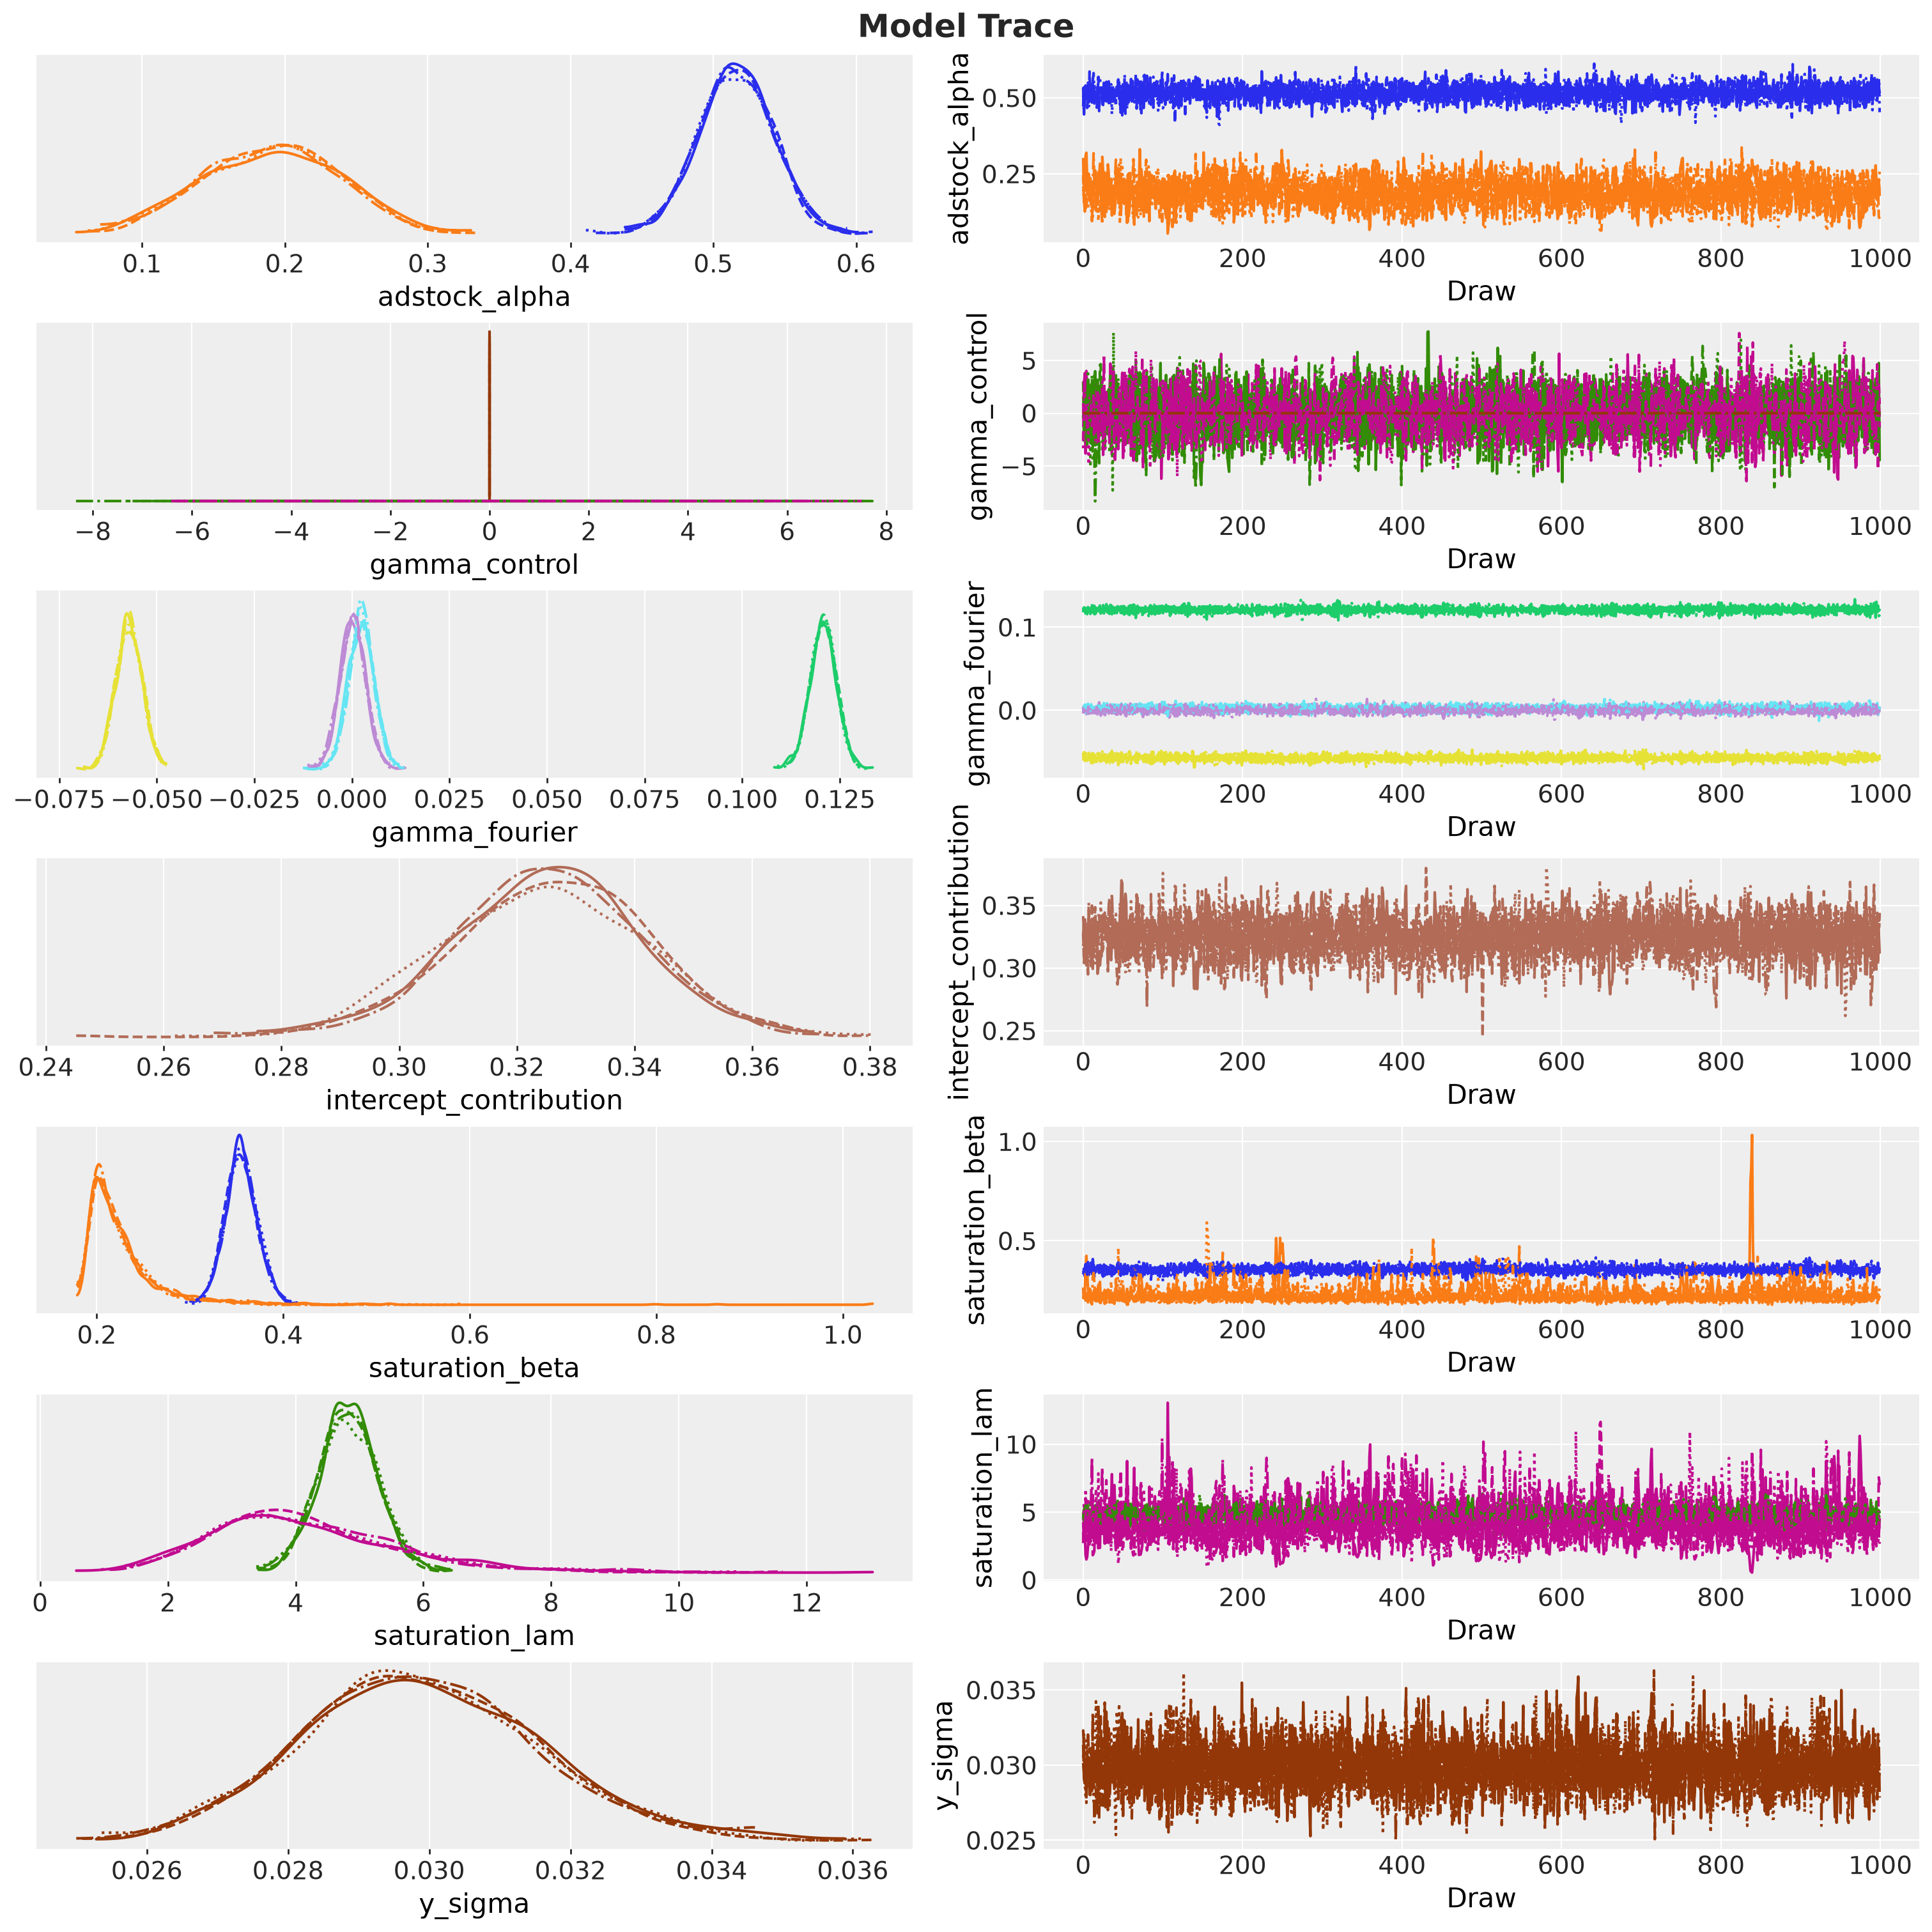

In [23]:
_ = azp.plot_trace_dist(
    mmm.fit_result,
    var_names=[
        "adstock_alpha",
        "gamma_control",
        "gamma_fourier",
        "intercept_contribution",
        "saturation_beta",
        "saturation_lam",
        "y_sigma",
    ],
    figure_kwargs={"figsize": (15, 15)},
)
plt.gcf().suptitle("Model Trace", fontsize=18, fontweight="bold");